In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import defaultdict


from sandbox.jordan8 import *

import json
import os

In [2]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

In [3]:
device = setup_device()

# Training

In [5]:
torch.manual_seed(0)
np.random.seed(0)

model = JordanNet(encode_dim=32)

training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)

eps_max = 1e-6

training_dataset = generate_training_datasets(matrices_per_class=2000,
                                              eps_range=(1e-16, eps_max),
                                              dimensions=training_dimensions)

model = train_jordan_net(
    model,
    training_dataset,
    num_epochs=50, 
    batch_size=64,
    lr=1e-3,
    device=device,
    train_transformer=True,
    patience=6,
    pth_suffix=f'_eps_max_{eps_max}',
    history_filename=f'sandbox/history_jordan8__eps_max_{eps_max}.csv',
)

Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Generating class with d=6, max_block_size=1...Done.
Generating class with d=6, max_block_size=2...Done.
Generating class with d=6, max_block_size=3...Done.
Generating class with d=6, max_block_size=4...Done.
Generating class with d=6, max_block_size=5...Done.
Generating class with d=6, max_block_size=6...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating c

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Epoch [1/50] | Train Loss: 1.214453 | Val Loss: 1.809459 | LR: 9.99e-04
Epoch [2/50] | Train Loss: 0.828653 | Val Loss: 1.655746 | LR: 9.96e-04
Epoch [3/50] | Train Loss: 0.707611 | Val Loss: 1.463160 | LR: 9.91e-04
Epoch [4/50] | Train Loss: 0.634014 | Val Loss: 1.293530 | LR: 9.84e-04
Epoch [5/50] | Train Loss: 0.577804 | Val Loss: 1.027928 | LR: 9.76e-04
Epoch [6/50] | Train Loss: 0.528854 | Val Loss: 0.924847 | LR: 9.65e-04
Epoch [7/50] | Train Loss: 0.486499 | Val Loss: 0.873721 | LR: 9.52e-04
Epoch [8/50] | Train Loss: 0.450622 | Val Loss: 0.632340 | LR: 9.38e-04
Epoch [9/50] | Train Loss: 0.418694 | Val Loss: 0.630495 | LR: 9.22e-04
Epoch [10/50] | Train Loss: 0.385382 | Val Loss: 0.507723 | LR: 9.05e-04
Epoch [11/50] | Train Loss: 0.374111 | Val Loss: 0.495996 | LR: 8.85e-04
Epoch [12/50] | Train Loss: 0.450055 | Val Loss: 2.177673 | LR: 8.64e-04
Epoch [13/50] | Train Loss: 0.711793 | Val Loss: 2.110562 | LR: 8.42e-04
Epoch [14/50] | Train Loss: 0.457669 | Val Loss: 1.073004 | 

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename))


In [6]:
torch.manual_seed(2026)
np.random.seed(2026)

model = JordanNet(encode_dim=32)

training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)

eps_max = 1e-4

training_dataset = generate_training_datasets(matrices_per_class=2000,
                                              eps_range=(1e-16, eps_max),
                                              dimensions=training_dimensions)

model = train_jordan_net(
    model,
    training_dataset,
    num_epochs=50, 
    batch_size=64,
    lr=1e-3,
    device=device,
    train_transformer=True,
    patience=6,
    pth_suffix=f'_eps_max_{eps_max}',
    history_filename=f'sandbox/history_jordan8__eps_max_{eps_max}.csv',
)

Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Generating class with d=6, max_block_size=1...Done.
Generating class with d=6, max_block_size=2...Done.
Generating class with d=6, max_block_size=3...Done.
Generating class with d=6, max_block_size=4...Done.
Generating class with d=6, max_block_size=5...Done.
Generating class with d=6, max_block_size=6...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating c

In [5]:
torch.manual_seed(123)
np.random.seed(123)

model = JordanNet(encode_dim=32)

training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)

eps_max = 0.1

training_dataset = generate_training_datasets(matrices_per_class=2000,
                                              eps_range=(1e-16, eps_max),
                                              dimensions=training_dimensions)

model = train_jordan_net(
    model,
    training_dataset,
    num_epochs=50, 
    batch_size=64,
    lr=1e-3,
    device=device,
    train_transformer=True,
    patience=6,
    pth_suffix=f'_eps_max_{eps_max}',
    history_filename=f'sandbox/history_jordan8__eps_max_{eps_max}.csv',
)

Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Generating class with d=6, max_block_size=1...Done.
Generating class with d=6, max_block_size=2...Done.
Generating class with d=6, max_block_size=3...Done.
Generating class with d=6, max_block_size=4...Done.
Generating class with d=6, max_block_size=5...Done.
Generating class with d=6, max_block_size=6...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating c

# Running tests

In [34]:
def run_test(model, d, matrices_per_class=1000, mode="random", eps=None, eps_range=None):
    model.eval()

    training_dataset = generate_training_datasets(
        matrices_per_class=matrices_per_class,
        dimensions=[d],
        mode=mode,
        eps=eps,
        eps_range=eps_range,
        device="cpu",
    )
    matrices, labels, features, masks, dists = training_dataset[d]
    loader = DataLoader(TensorDataset(features, labels, masks, dists), batch_size=64, shuffle=False)

    predicted_classes = []
    true_classes = labels.cpu().tolist()
    kl_avg = 0.0

    for batch_features, batch_labels, batch_masks, batch_dists in loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        batch_masks = batch_masks.to(device)
        batch_dists = batch_dists.to(device)

        logits = model(d, batch_features, masks=batch_masks)
        loss = kl_loss(logits, batch_dists)

        preds = torch.argmax(logits, dim=-1)
        predicted_classes += preds.cpu().tolist()
        kl_avg += loss.item() * batch_features.size(0)

    kl_avg /= len(loader.dataset)
    # print(f"Test KL Loss: {kl_avg:.6f}")

    return true_classes, predicted_classes, kl_avg

def test_jordan_net(model, d, eps_max, matrices_per_class=1000, filename=None):
    if filename is None:
        filename = f"sandbox/jordan8_results/eps_max_{eps_max}/results_{d}.json"

    results = []

    for eps in [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1]:
        print(f"Testing with eps={eps}")
        true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="random", eps=eps)
        results.append({
            "eps": eps,
            "true_classes": true_classes,
            "predicted_classes": predicted_classes,
            "kl_avg": kl_avg,
        })
    
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)
    
def visualize_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f) 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, d+1)))
        disp.plot(cmap=plt.cm.Blues)
        title = f"{'eps='+str(eps) if eps != 'ortho' else 'ortho'}. KL Loss: {result['kl_avg']:.6f}, accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        plt.title(title)
        plt.show()
    
def print_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f)

    print(f"\nTest results for dimension {d}:") 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        title = f"\t{'eps='+f'{eps:<10}' if eps != 'ortho' else 'ortho     '}\t KL Loss: {result['kl_avg']:.6f},\t accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        print(title)

In [59]:
torch.manual_seed(0)
np.random.seed(0)
for eps_max in [0.1]:
    os.makedirs(f"sandbox/jordan8_results/eps_max_{eps_max}/", exist_ok=True)
    model = JordanNet(encode_dim=32)
    training_dimensions = [4, 6, 9, 12, 15, 28]
    for d in training_dimensions:
        model.add_dimension(d)
    model.load_state_dict(torch.load(f"sandbox/model_jordan8_eps_max_{eps_max}.pth"))
    model.to(device)
    for d in training_dimensions:
        test_jordan_net(model, d, eps_max=eps_max, matrices_per_class=1000)

Testing with eps=0
Generating class with d=4, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_16400\1969214547.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_eps

Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=1e-06
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=1e-05
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.0001
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.001
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class 

# Results visualization

In [3]:
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict

def vizualize_result(d, eps_max_list=[1e-6, 0.0001, 0.01], acc_within=2):
    filename = f"results_{d}.json"
    data_kl = defaultdict(dict)
    data_acc = defaultdict(dict)
    data_acc_pm = defaultdict(dict)

    # 1. Load Data
    for eps_max in eps_max_list:
        folder_path = f"sandbox/jordan8_results/eps_max_{eps_max}/"
        file_path = os.path.join(folder_path, filename)
        if not os.path.exists(file_path): continue
        
        with open(file_path, 'r') as f:
            results = json.load(f)
        for entry in results:
            curr_eps = entry.get("eps")
            # Convert "ortho" or strings to floats, handle 0
            try:
                eps_val = float(curr_eps) if curr_eps != "ortho" else "ortho"
            except:
                continue

            preds = entry.get("predicted_classes", [])
            trues = entry.get("true_classes", [])

            acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
            acc_pm = sum(1 for p, t in zip(preds, trues) if abs(p-t) <= acc_within) / len(trues) if trues else 0
            
            data_kl[eps_max][eps_val] = entry.get("kl_avg")
            data_acc[eps_max][eps_val] = acc
            data_acc_pm[eps_max][eps_val] = acc_pm

    # Helper to find minimum non-zero epsilon for the linear threshold
    all_vals = []
    for em in eps_max_list:
        all_vals.extend([e for e in data_kl[em].keys() if isinstance(e, (int, float)) and e > 0])
    
    # Define linthresh: the point where the scale switches from linear to log
    # We set it slightly smaller than the smallest non-zero epsilon
    min_nonzero = min(all_vals) if all_vals else 1e-7
    lin_thresh = min_nonzero / 10 

    metrics = [
        (data_kl, "KL Divergence", "kl"),
        (data_acc, "Accuracy", "acc"),
        (data_acc_pm, f"Accuracy@±{acc_within}", "acc_pm")
    ]

    for data_dict, title, file_name in metrics:
        plt.figure()
        colors = plt.cm.get_cmap('tab10').colors
        
        for i, eps_max in enumerate(eps_max_list):
            # Filter and sort keys
            all_epsilons = sorted([e for e in data_dict[eps_max].keys() if isinstance(e, (int, float))])
            color = colors[i % len(colors)]
            
            # Solid line for e <= eps_max
            x_solid = [e for e in all_epsilons if e <= eps_max]
            y_solid = [data_dict[eps_max][e] for e in x_solid]
            plt.plot(x_solid, y_solid, linestyle="-", marker="o", color=color, label=fr"$\varepsilon_{{max}}={eps_max}$")
            
            # Dotted line for e > eps_max
            x_dotted = [e for e in all_epsilons if e >= eps_max]
            y_dotted = [data_dict[eps_max][e] for e in x_dotted]
            plt.plot(x_dotted, y_dotted, linestyle="--", marker="o", color=color)

        # Apply SymLog Scale
        # linthresh defines the range [-linthresh, linthresh] that is linear
        plt.xscale('symlog', linthresh=lin_thresh)
        
        plt.xlabel(r"$\varepsilon$")
        plt.ylabel(title)
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.legend()
        plt.savefig(f"latex/images/j8_eps_{file_name}_d{d}.pdf")
        plt.show()

C:\Users\micha\AppData\Local\Temp\ipykernel_2228\4038928752.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors


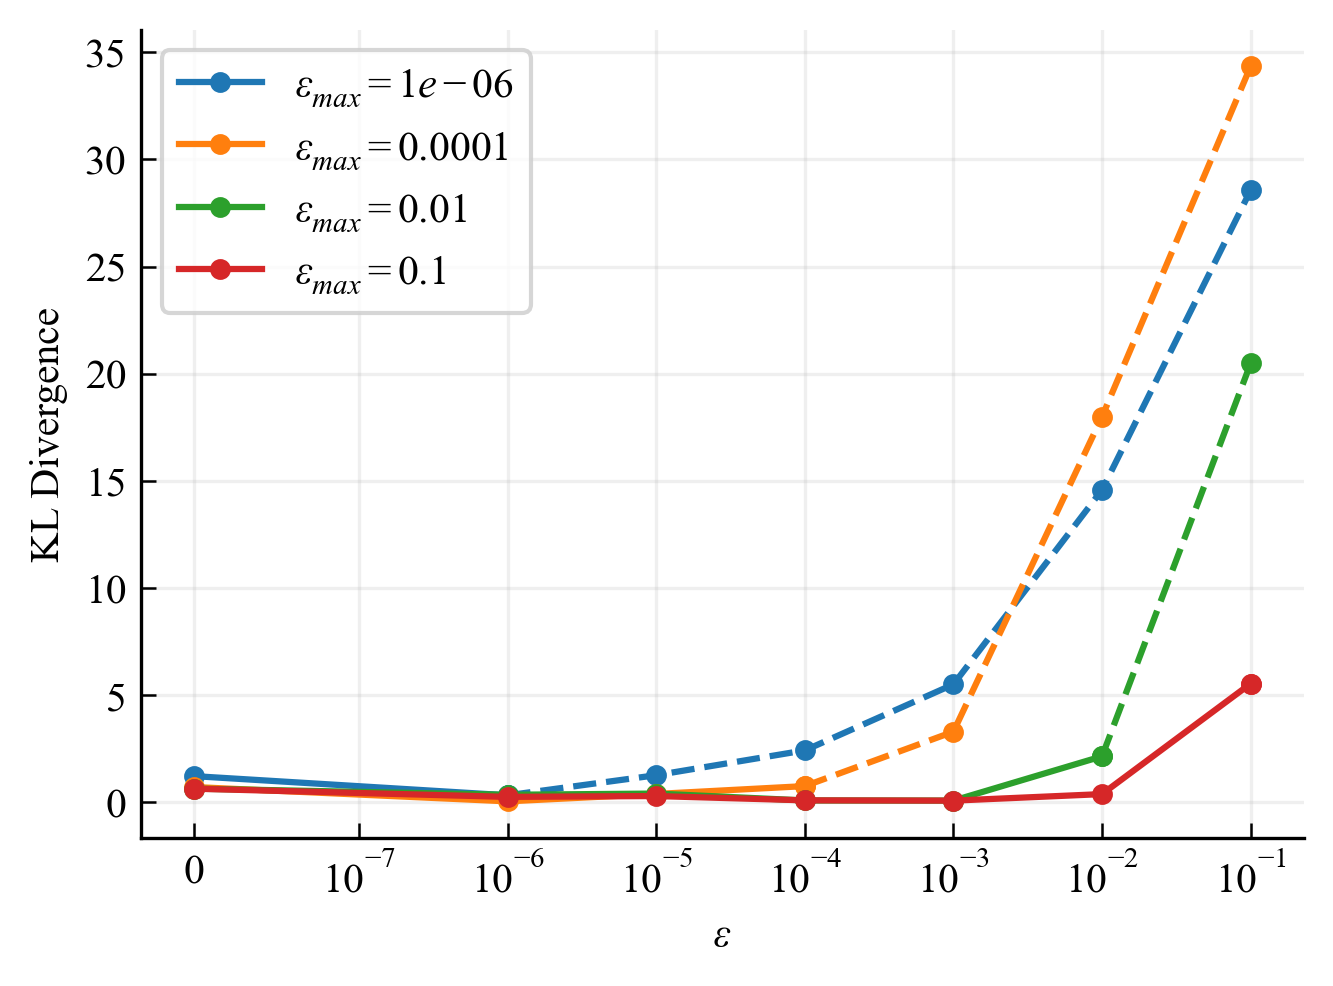

C:\Users\micha\AppData\Local\Temp\ipykernel_2228\4038928752.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors


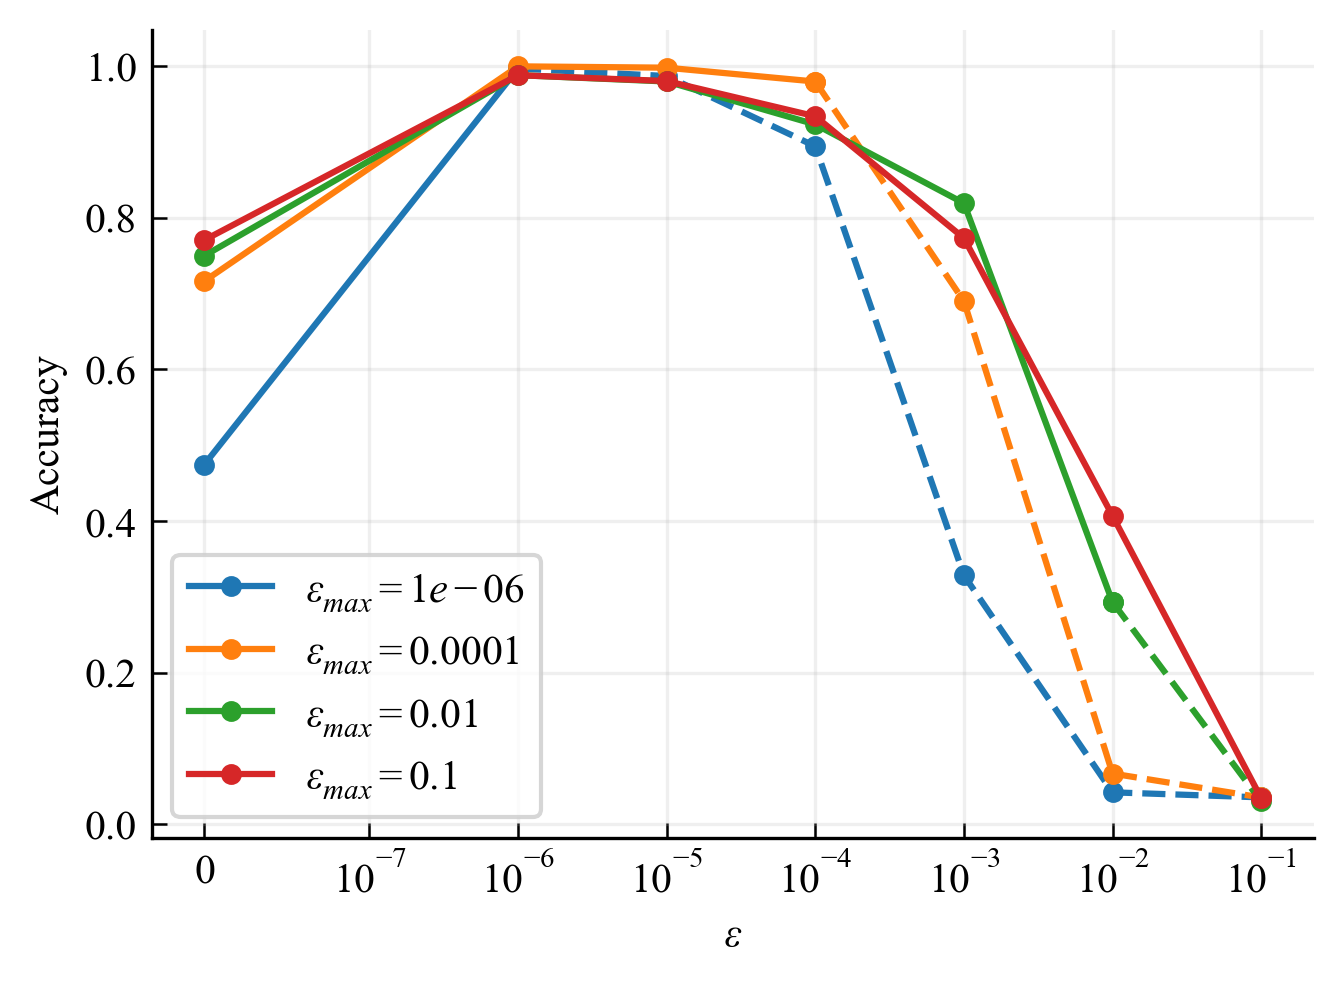

C:\Users\micha\AppData\Local\Temp\ipykernel_2228\4038928752.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10').colors


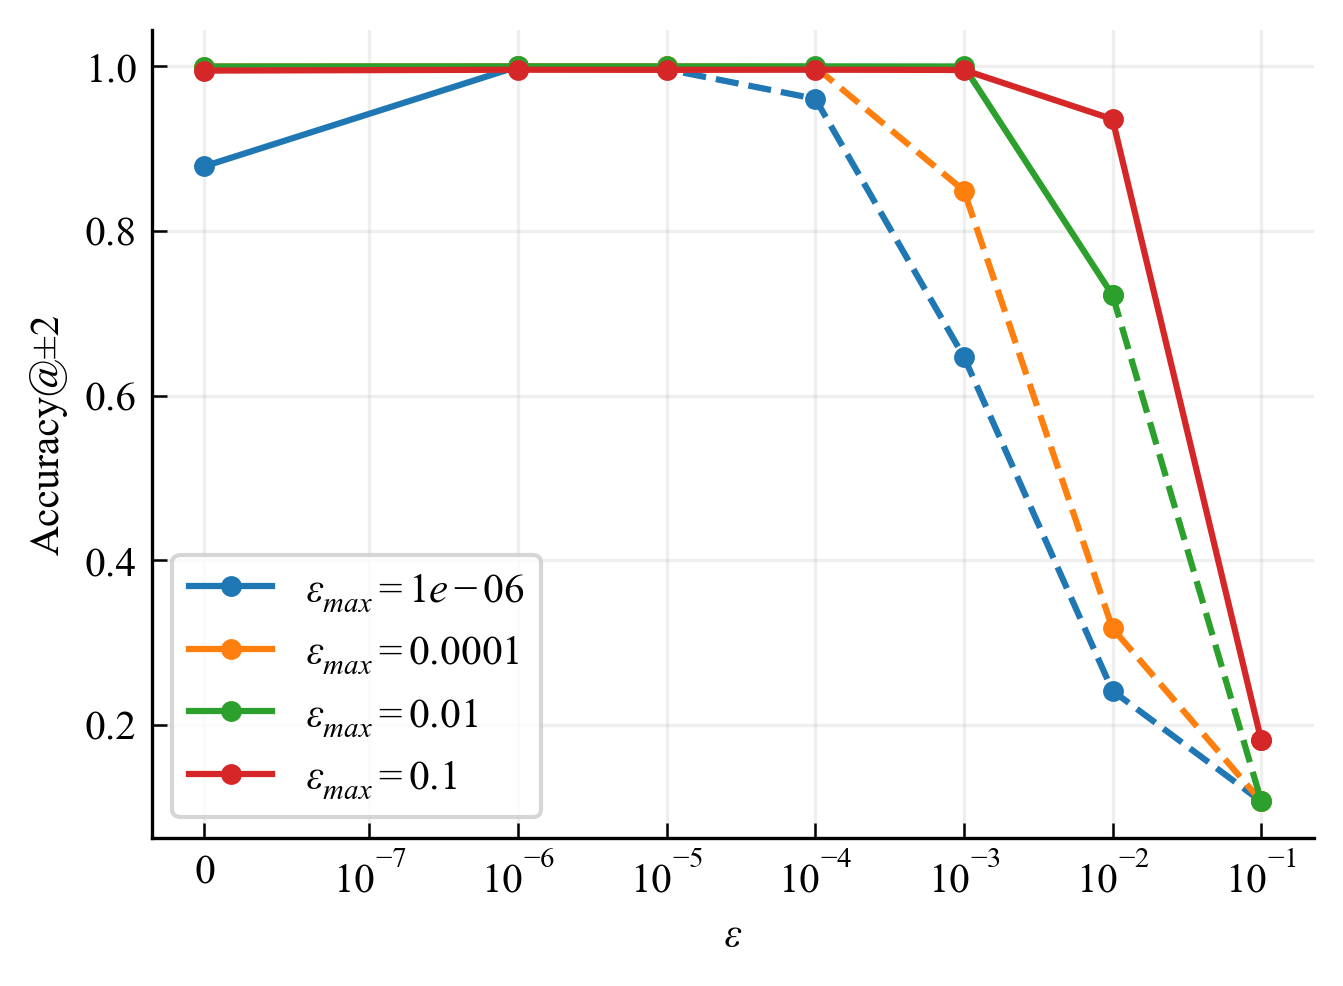

In [ ]:
vizualize_result(d=15, eps_max_list=[1e-6, 0.0001, 0.01, 0.1])